# North Sea algae blooms in the ICOS SOCAT zarr store

**Question.** When can we detect a phytoplankton bloom on the North Sea from
sea-surface temperature (SST), and how does it show up in surface pCO₂?

**Data.** The ICOS Carbon Portal publishes three zarr stores at
<https://zarr.icos-cp.eu>:

| Store | Topic |
|---|---|
| `icos-socat.zarr` | Surface Ocean CO₂ Atlas — shipboard & buoy underway pCO₂/fCO₂, SST, salinity |
| `icos-obspack.zarr` | Atmospheric station network (towers) |
| `icos-fluxnet.zarr` | Terrestrial ecosystem eddy-covariance fluxes |

Only `icos-socat.zarr` is marine. It contains 477 top-level zarr **groups**,
one per cruise / buoy deployment, indexed by SOCAT expocode. Each group
holds 1-D arrays sharing the same `time` axis: `time`, `lat`, `lon`,
`Temp` (SST °C), `pCO2` (µatm), `fCO2` (µatm), `P_sal` (psu), plus matching
`*_QC` flags (WOCE: 2 = good).

**Approach.**
1. List the stores at the endpoint.
2. Open `icos-socat.zarr` and scan every cruise group for any sample inside
   a North Sea bounding box (51-62 °N, -4-10 °E).
3. Pick a high-value North Sea station — the **Thornton Buoy** (VLIZ),
   a fixed mooring at 51.58 °N / 2.99 °E with a continuous 2018-2020 record.
4. Compute monthly climatology and plot SST + pCO₂.
5. Detect bloom episodes: pCO₂ drawn down well below atmospheric
   *and* SST rising — the spring-bloom fingerprint.
6. Separate the **thermal** vs **biological** drivers of pCO₂.


*Advanced example — notebook 10 of the [sample series](README.md). Builds on notebook 05 (SOCAT basics). Sections 1–9 need no account; section 10 (air–sea flux) reads ERA-5 winds from [DestinE EarthDataHub](https://earthdatahub.destine.eu/) and needs its free token (`EDH_TOKEN` or `~/.netrc`).*

## 1. Setup

In [1]:
import json, os
import requests
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import fsspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

ENDPOINT  = "https://zarr.icos-cp.eu"
SOCAT_URL = f"{ENDPOINT}/icos-socat.zarr"

# The SOCAT store is in Zarr v2 format and ships a 12 MB consolidated-metadata
# file (.zmetadata) at its root listing every child group. The endpoint does
# NOT expose an HTTP directory listing, so we MUST use that index — open the
# store with zarr.open_consolidated() so the call fails loudly if .zmetadata
# can't be fetched, instead of silently returning an empty group.
def open_socat():
    return zarr.open_consolidated(fsspec.get_mapper(SOCAT_URL), mode="r")

print("zarr", zarr.__version__, "| xarray", xr.__version__, "| fsspec", fsspec.__version__)

zarr 3.3.0 | xarray 2026.7.0 | fsspec 2026.3.0


## 2. What stores does the endpoint expose?

In [2]:
index = requests.get(ENDPOINT, timeout=30).json()
index

{'stores': ['icos-fluxnet.zarr',
  'icos-obspack.zarr',
  'icos-socat.zarr',
  'socat-gridded.zarr',
  'socat.zarr'],
 'agent_guide': {'service': 'ICOS environmental-data Zarr proxy: atmosphere / ecosystem / ocean datasets served as Zarr v2 over HTTP, each minting a data passport on access.',
  'how_to_use': "Every store is self-describing — GET /{store}/agent_guide for how to open, filter, and cite it (layout, QC keep-rule, query API, citation). Open one directly with xarray.open_zarr('<base>/<store>', consolidated=True).",
  'stores': {'icos-fluxnet.zarr': {'agent_guide': 'https://zarr.icos-cp.eu/icos-fluxnet.zarr/agent_guide',
    'open': "xarray.open_zarr('https://zarr.icos-cp.eu/icos-fluxnet.zarr', consolidated=True)",
    'croissant': 'https://zarr.icos-cp.eu/icos-fluxnet.zarr/croissant'},
   'icos-obspack.zarr': {'agent_guide': 'https://zarr.icos-cp.eu/icos-obspack.zarr/agent_guide',
    'open': "xarray.open_zarr('https://zarr.icos-cp.eu/icos-obspack.zarr', consolidated=True)",


Three stores. For marine biogeochemistry, **`icos-socat.zarr`** is the one.
The other two are atmospheric and terrestrial.

## 3. Open the SOCAT store and look at its structure

The SOCAT store is in Zarr v2 format and ships a 12 MB **consolidated metadata**
file (`.zmetadata`) at its root that enumerates every child group and its
attributes. The endpoint does **not** expose an HTTP directory listing, so
opening the store without that consolidated index silently returns an empty
group:

```python
zarr.open_group(mapper, use_consolidated=False).group_keys()   # -> []  (silently)
zarr.open_consolidated(mapper).group_keys()                    # -> 477 (correct)
```

Always use `open_consolidated()` against this endpoint — it raises loudly if
`.zmetadata` can't be fetched, instead of looking like an empty dataset.

In [3]:
root = open_socat()
cruises = sorted(root.group_keys())
assert len(cruises) > 0, "Got 0 groups — .zmetadata fetch likely failed; check network / clear ./zarr_cache"
print(f"Total cruises (zarr groups): {len(cruises)}")
print(f"First 5 group names:        {cruises[:5]}")

Total cruises (zarr groups): 477
First 5 group names:        ['119920180214', '119920220401', '119920220701', '119920221001', '119920230501']


In [4]:
# Peek at one group: variables, units, attrs
example = root[cruises[0]]
print(f"--- {cruises[0]} ---")
print(f"station         : {example.attrs.get('station_name')!r}")
print(f"organisation    : {example.attrs.get('responsible_organization_label')!r}")
_lat, _lon = example.attrs.get('latitude'), example.attrs.get('longitude')
_pos = (f"(lat {_lat:.3f}, lon {_lon:.3f})" if _lat is not None and _lon is not None else "(moving platform — no fixed position)")
print(f"fixed position? : {example.attrs.get('fixed')}  {_pos}")
print(f"time coverage   : {example.attrs.get('time_start')}  ->  {example.attrs.get('time_end')}")
print(f"source DOI      : {example.attrs.get('collection_doi')}")
print()
print(f"{'variable':30s} {'units':10s} long_name")
for v in example.array_keys():
    a = example[v]
    print(f"{v:30s} {a.attrs.get('units',''):10s} {a.attrs.get('long_name','')}")

--- 119920180214 ---
station         : 'Thornton Buoy'
organisation    : 'VLIZ'
fixed position? : True  (lat 51.580, lon 2.993)
time coverage   : 2018-02-14T16:20:00Z  ->  2020-07-10T20:00:31Z
source DOI      : https://doi.org/10.18160/BCFM-GNVA

variable                       units      long_name
CO2_Mole_Fraction_umol_mol_1   umol mol-1 
Cell_Pressure_mbar                        
P_sal                          psu        practical salinity
P_sal_QC                       psu        quality flag (int)
Temp                           degC       water temperature
Temp_QC                        degC       quality flag (int)
fCO2                           uatm       CO2 fugacity (water), SST
fCO2_QC                        uatm       quality flag (int)
lat                                       
lon                                       
pCO2                           uatm       CO2 partial pressure (water), SST
pCO2_QC                        uatm       quality flag (int)
pCO2_SST_precorr    

Every cruise group carries rich metadata — citation, DOI, organisation,
station class, and a `time_start`/`time_end`. The arrays themselves are plain
1-D series sharing the cruise `time` axis. QC follows WOCE: flag `2` is good
data, others are questionable or missing.

## 4. Which cruises sample the North Sea?

I'm using a generous box around the North Sea: latitude 51-62 °N,
longitude -4-10 °E. I read just the `lat`/`lon` arrays from each group
(small) and test whether any sample falls inside the box.

The scan over all 477 cruises takes ~1-2 minutes against the live endpoint.
To make the notebook re-runnable quickly, we cache the result to
`northsea_cruises.json` and reuse it when present.

In [5]:
import os, time

LAT_MIN, LAT_MAX = 51.0, 62.0
LON_MIN, LON_MAX = -4.0, 10.0
CACHE = "northsea_cruises.json"

def scan_north_sea():
    hits = []
    t0 = time.time()
    for i, name in enumerate(cruises):
        try:
            g = root[name]
            if "lat" not in g or "lon" not in g:
                continue
            lat = g["lat"][:]
            lon = g["lon"][:]
            m = np.isfinite(lat) & np.isfinite(lon)
            if not m.any():
                continue
            lat, lon = lat[m], lon[m]
            inside = (lat >= LAT_MIN) & (lat <= LAT_MAX) & (lon >= LON_MIN) & (lon <= LON_MAX)
            if inside.any():
                hits.append({
                    "expocode": name,
                    "n_total": int(lat.size),
                    "n_in_box": int(inside.sum()),
                    "lat_range": [float(lat.min()), float(lat.max())],
                    "lon_range": [float(lon.min()), float(lon.max())],
                    "platform_name": g.attrs.get("station_name"),
                    "time_start":    g.attrs.get("time_start"),
                    "time_end":      g.attrs.get("time_end"),
                })
        except Exception:
            pass
        if (i+1) % 100 == 0:
            print(f"  scanned {i+1}/{len(cruises)}  ({time.time()-t0:.0f}s elapsed)")
    return hits

if os.path.exists(CACHE):
    with open(CACHE) as f:
        hits = json.load(f)
    print(f"Loaded {len(hits)} North Sea cruises from cache ({CACHE})")
else:
    hits = scan_north_sea()
    with open(CACHE, "w") as f:
        json.dump(hits, f, indent=2)
    print(f"Wrote {len(hits)} entries to {CACHE}")

  scanned 100/477  (1s elapsed)


  scanned 200/477  (2s elapsed)


  scanned 300/477  (3s elapsed)


  scanned 400/477  (4s elapsed)


Wrote 318 entries to northsea_cruises.json


In [6]:
# Top 15 by number of samples inside the North Sea box
ns = pd.DataFrame(hits)
ns = ns[ns["expocode"] != "_obs"]      # drop the legacy combined "_obs" pseudo-group
ns = ns.sort_values("n_in_box", ascending=False).reset_index(drop=True)
ns.head(15)[["expocode", "platform_name", "n_in_box", "n_total", "time_start", "time_end"]]

,expocode,platform_name,n_in_box,n_total,time_start,time_end
0,11SS20250401,Simon Stevin,30331,30331,2025-04-01T00:02:00Z,2025-06-09T20:10:01Z
1,BHNQ20220628,Sea-Cargo Express,24231,31928,2022-06-28T05:23:02Z,2022-08-08T00:11:25Z
2,11SS20210601,Simon Stevin,23630,23630,2021-06-01T00:00:00.322Z,2021-06-30T20:10:00.294Z
3,119920220701,Thornton Buoy,21000,21000,2022-07-01T00:00:01Z,2022-09-30T20:06:03Z
4,11SS20220601,Simon Stevin,19608,19608,2022-06-01T00:04:00.309Z,2022-06-30T22:27:00.430Z
5,11SS20210301,Simon Stevin,19260,19260,2021-03-01T05:00:15.434Z,2021-03-31T20:10:00.442Z
6,58G220230201,G.O. Sars,16859,16859,2023-02-02T15:15:26Z,2023-03-09T13:26:47Z
7,11SS20240601,Simon Stevin,16342,16342,2024-06-01T00:02:00Z,2024-06-30T19:21:30Z
8,MLSC20251001,Sea-Cargo Express,16221,21275,2025-10-01T00:10:17Z,2025-10-31T23:58:02Z
9,11SS20240501,Simon Stevin,15679,15679,2024-05-01T00:02:00Z,2024-05-31T20:10:00Z


Clear groupings:

* **`1199*`** — VLIZ **Thornton Buoy**, a fixed mooring in the southern North Sea
  (51.58 °N / 2.99 °E). Multiple deployments. Best signal-to-noise for resolving the
  seasonal cycle because position is fixed.
* **`11SS*`** — Belgian **RV Simon Stevin** monthly transects in the southern North Sea.
* **`58G2*`, `MLSC*`** — central and northern North Sea cruises (lat 57-63 °N).

Map them quickly:

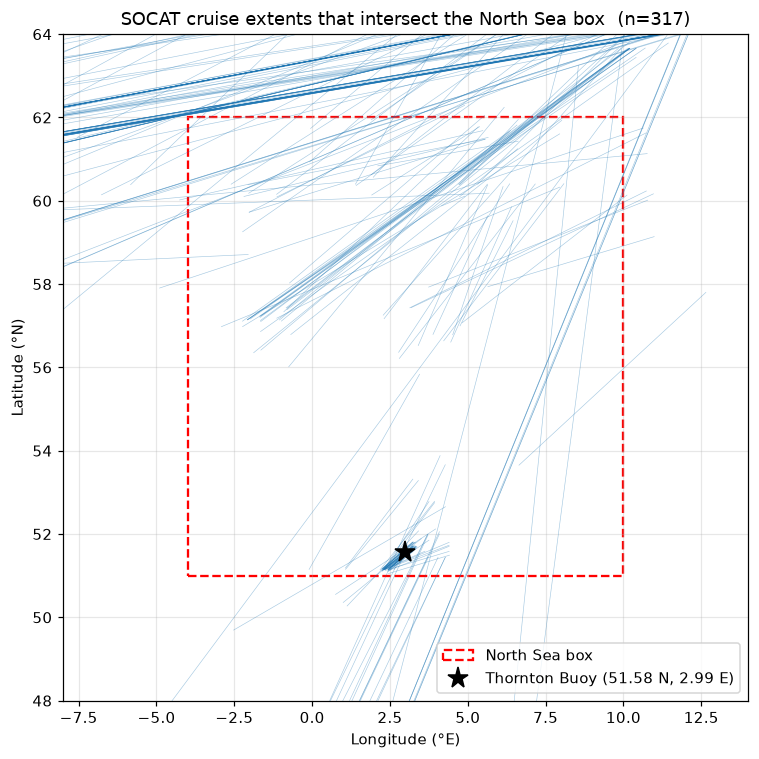

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
for h in hits:
    if h["expocode"] == "_obs":
        continue
    lat0, lat1 = h["lat_range"]
    lon0, lon1 = h["lon_range"]
    ax.plot([lon0, lon1], [lat0, lat1], "-", lw=0.4, alpha=0.4, color="tab:blue")
# North Sea box
ax.add_patch(plt.Rectangle((LON_MIN, LAT_MIN), LON_MAX-LON_MIN, LAT_MAX-LAT_MIN,
                           fill=False, edgecolor="red", lw=1.5, ls="--",
                           label="North Sea box"))
# Thornton Buoy
ax.plot(2.993, 51.580, "k*", ms=14, label="Thornton Buoy (51.58 N, 2.99 E)")
ax.set_xlim(-8, 14); ax.set_ylim(48, 64)
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.set_title(f"SOCAT cruise extents that intersect the North Sea box  (n={len(ns)})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()

## 5. Zoom in on Thornton Buoy — continuous fixed-station record

In [8]:
GID = "119920180214"   # Thornton Buoy deployment 2018-02 → 2020-07
g = root[GID]   # reuses the same consolidated, cached `root` from above
print(f"Station    : {g.attrs.get('station_name')}")
print(f"Operator   : {g.attrs.get('responsible_organization')}")
print(f"Position   : {g.attrs.get('latitude'):.4f} N, {g.attrs.get('longitude'):.4f} E (fixed = {g.attrs.get('fixed')})")
print(f"Period     : {g.attrs.get('time_start')}  ->  {g.attrs.get('time_end')}")
print(f"DOI        : https://doi.org/{g.attrs.get('source_doi')}")

Station    : Thornton Buoy
Operator   : Vlaams Instituut voor de Zee (Flanders Marine Institute)
Position   : 51.5799 N, 2.9932 E (fixed = True)
Period     : 2018-02-14T16:20:00Z  ->  2020-07-10T20:00:31Z
DOI        : https://doi.org/11676/n94jijAEWH95fMNn8Mwd4I0M


In [9]:
# Load arrays into a pandas DataFrame, keeping only WOCE-good data
t       = g["time"][:]
sst     = g["Temp"][:];      sst_qc  = g["Temp_QC"][:]
pco2    = g["pCO2"][:];      pco2_qc = g["pCO2_QC"][:]
sal     = g["P_sal"][:];     sal_qc  = g["P_sal_QC"][:]

ok = (sst_qc == 2) & (pco2_qc == 2)
df = pd.DataFrame({"sst": sst[ok], "pco2": pco2[ok], "sal": np.where(sal_qc[ok] == 2, sal[ok], np.nan)},
                  index=pd.to_datetime(t[ok])).sort_index()
df.index.name = "time"
print(f"Good records       : {len(df):,}")
print(f"Time span          : {df.index.min()}  ->  {df.index.max()}")
print(f"SST  range         : {df['sst'].min():.2f}  -  {df['sst'].max():.2f}  °C")
print(f"pCO2 range         : {df['pco2'].min():.1f} - {df['pco2'].max():.1f}  µatm   (atmospheric ~410)")
df.head()

Good records       : 10,639
Time span          : 2018-02-14 16:20:00  ->  2020-07-10 20:00:31
SST  range         : 3.33  -  21.16  °C
pCO2 range         : 111.3 - 500.2  µatm   (atmospheric ~410)


,sst,pco2,sal
time,,,
2018-02-14 16:20:00,6.5083,375.9,34.2015
2018-02-16 16:20:00,6.7340,370.3,34.4569
2018-02-16 20:20:00,6.5411,372.0,34.4155
2018-02-17 00:20:00,6.4033,379.0,34.0983
2018-02-17 04:20:00,6.6474,371.5,34.4635


In [10]:
# Daily means smooth out tidal / diurnal noise
daily = df.resample("1D").mean().dropna(subset=["sst", "pco2"])
print(f"Daily-mean days kept: {len(daily)}")
daily.tail()

Daily-mean days kept: 385


,sst,pco2,sal
time,,,
2020-07-06,16.595917,437.100000,34.566417
2020-07-07,16.731200,441.482500,34.570050
2020-07-08,16.764700,444.793333,34.603367
2020-07-09,16.769617,439.469167,34.635067
2020-07-10,16.793017,442.609167,34.671400


## 6. Monthly climatology — the seasonal cycle

In [11]:
clim = (daily.assign(month=daily.index.month)
              .groupby("month")
              .agg(sst_mean=("sst","mean"),
                   pco2_mean=("pco2","mean"),
                   pco2_min=("pco2","min"),
                   pco2_max=("pco2","max"),
                   n_days=("sst","size")))
clim.style.format({"sst_mean":"{:.2f}", "pco2_mean":"{:.0f}",
                   "pco2_min":"{:.0f}", "pco2_max":"{:.0f}"})

,sst_mean,pco2_mean,pco2_min,pco2_max,n_days
month,,,,,
1,8.30,420,415,427,8
2,5.95,360,312,381,14
3,5.69,284,227,346,41
4,9.03,175,118,247,62
5,12.19,177,117,269,85
6,15.82,341,251,462,60
7,18.85,426,336,471,56
8,19.48,436,422,455,31
9,18.52,423,387,442,28


Read this row by row and the spring bloom jumps out:

* **Jan**: SST 8 °C, pCO₂ ~420 µatm → near atmospheric, no biology.
* **Feb-Mar**: SST drops to ~6 °C *but pCO₂ collapses* → not thermal,
  it's **photosynthesis** drawing CO₂ down as light returns.
* **Apr-May**: pCO₂ minima of **117 µatm**, ~290 µatm below atmospheric →
  peak bloom. SST climbs through 9-12 °C.
* **Jun**: bloom dies, respiration starts to rebuild pCO₂.
* **Jul-Aug**: SST peaks (~19 °C), pCO₂ back above atmospheric — purely
  thermal solubility effect now dominates.

Thermally, every 1 °C of warming should raise pCO₂ by ~4.23 %
(Takahashi *et al.*, 1993). The observed drop in spring is the opposite
direction from thermal — biology wins by a wide margin.

## 7. Full time-series plot — SST and pCO₂ together

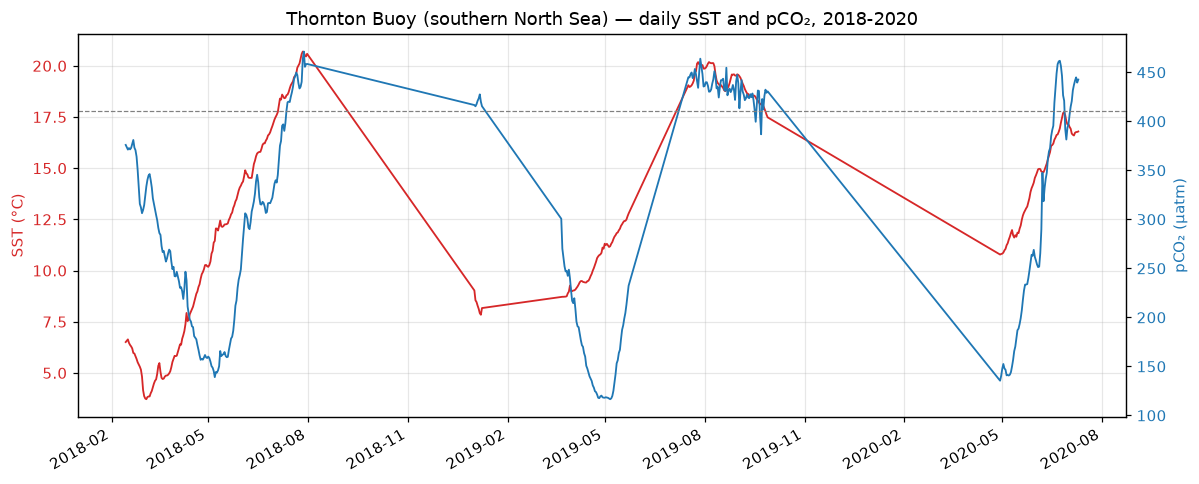

In [12]:
ATM = 410.0    # rough atmospheric pCO2 reference for 2018-2020

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(daily.index, daily["sst"], color="tab:red", lw=1.2, label="SST")
ax1.set_ylabel("SST (°C)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(daily.index, daily["pco2"], color="tab:blue", lw=1.2, label="pCO2 (water)")
ax2.axhline(ATM, color="grey", lw=0.8, ls="--", label=f"atm ~{ATM:.0f} µatm")
ax2.set_ylabel("pCO₂ (µatm)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax1.set_title("Thornton Buoy (southern North Sea) — daily SST and pCO₂, 2018-2020")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
ax1.grid(alpha=0.3)
fig.tight_layout()

Visual confirmation: each spring, the blue curve plunges hundreds of µatm
below atmospheric **before** the red SST curve has risen much — biology leads
warming. By midsummer pCO₂ is back near or above atmospheric, riding the
thermal expansion.

## 8. Automatic bloom-episode detection

A simple operational definition that works on this station:

* pCO₂ is more than **40 µatm below atmospheric** (a value well outside
  winter mixing-driven variability), **and**
* SST has risen over the **previous 14 days** (excludes wintertime
  drawdown anomalies).

Group consecutive (≤3 d gap) flagged days into episodes.

In [13]:
daily["pco2_dev"] = daily["pco2"] - ATM
daily["sst_d14"]  = daily["sst"].diff(periods=14)

bloom_mask = (daily["pco2_dev"] < -40) & (daily["sst_d14"] > 0)

runs, start, last = [], None, None
for d in daily.index[bloom_mask]:
    if last is None or (d - last).days > 3:
        if start is not None:
            runs.append((start, last))
        start = d
    last = d
if start is not None:
    runs.append((start, last))

episodes = pd.DataFrame([{
    "start": s.date(), "end": e.date(), "days": (e-s).days + 1,
    "min_pCO2_uatm": daily.loc[s:e, "pco2"].min(),
    "mean_SST_C":    daily.loc[s:e, "sst"].mean(),
} for s, e in runs])
episodes

,start,end,days,min_pCO2_uatm,mean_SST_C
0,2018-03-15,2018-07-05,113,139.033333,11.222642
1,2019-03-29,2019-05-23,56,116.533333,10.613437
2,2020-05-13,2020-06-13,32,170.165289,13.785394


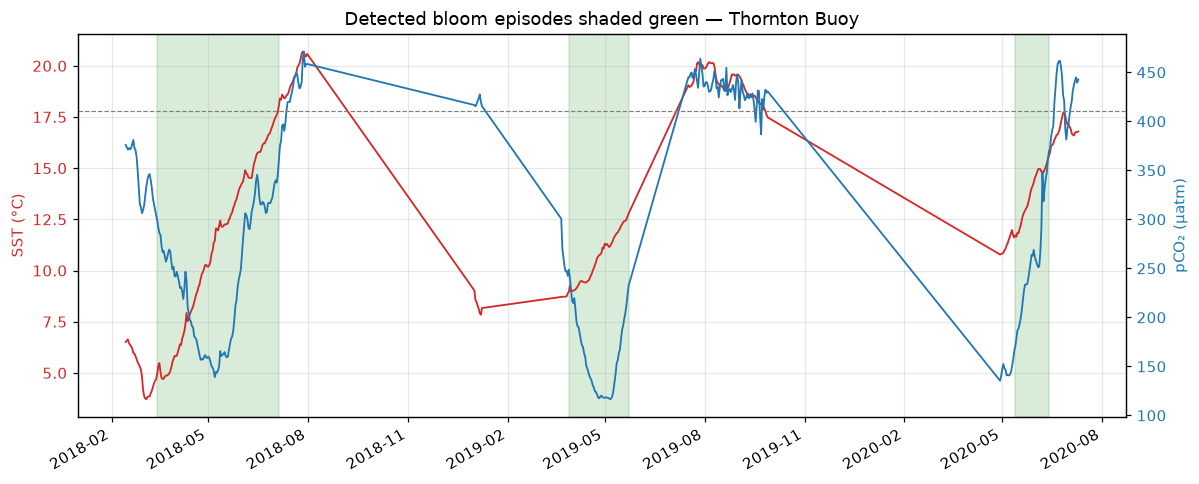

In [14]:
# Replot with bloom episodes shaded
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(daily.index, daily["sst"], color="tab:red", lw=1.2)
ax1.set_ylabel("SST (°C)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(daily.index, daily["pco2"], color="tab:blue", lw=1.2)
ax2.axhline(ATM, color="grey", lw=0.8, ls="--")
ax2.set_ylabel("pCO₂ (µatm)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

for s, e in runs:
    ax1.axvspan(s, e, color="green", alpha=0.15)

ax1.set_title("Detected bloom episodes shaded green — Thornton Buoy")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
ax1.grid(alpha=0.3)
fig.tight_layout()

## 9. Separating thermal vs biological pCO₂

The Takahashi-1993 relation lets us isolate the part of pCO₂ change
that is *purely* a temperature-solubility response:

$$
\mathrm{pCO_2^{\,thermal}}(t) = \overline{\mathrm{pCO_2}}\;\exp\!\bigl[\,0.0423\,(\mathrm{SST}(t)-\overline{\mathrm{SST}})\bigr]
$$

The **biological** component is then the residual `pCO2_obs - pCO2_thermal`:
strongly negative during blooms, positive when respiration / mixing dominate.

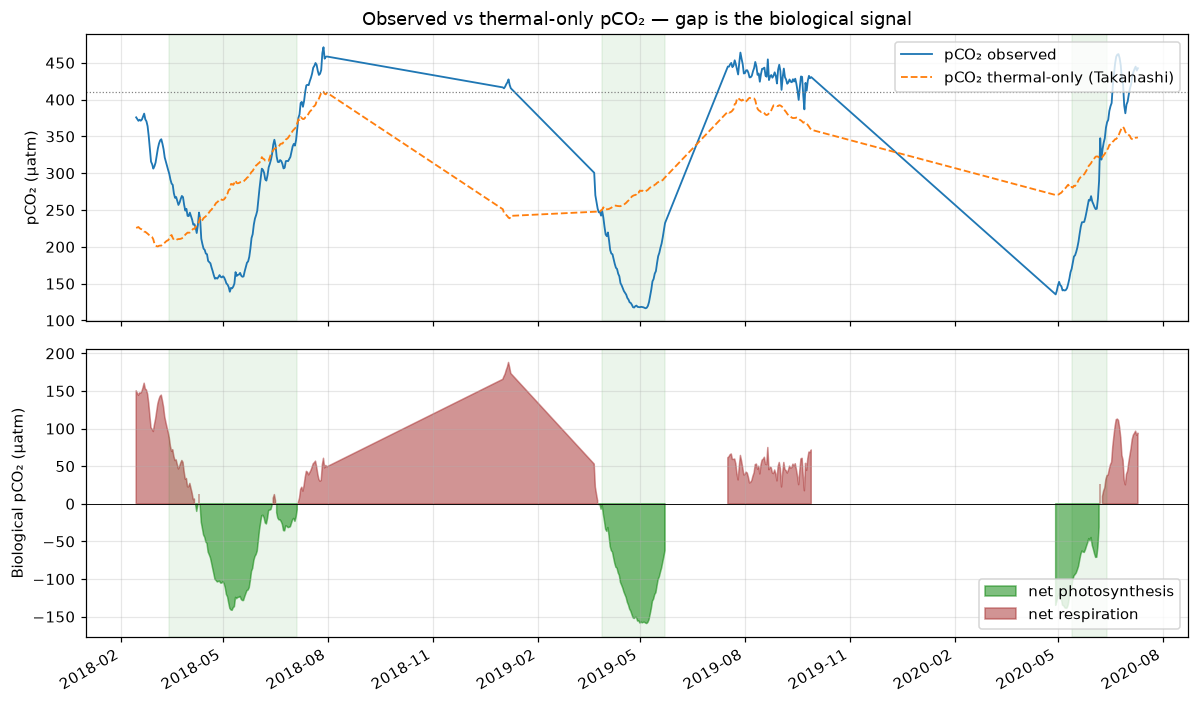

In [15]:
pco2_mean = daily["pco2"].mean()
sst_mean  = daily["sst"].mean()
daily["pco2_thermal"]    = pco2_mean * np.exp(0.0423 * (daily["sst"] - sst_mean))
daily["pco2_biological"] = daily["pco2"] - daily["pco2_thermal"]

fig, (axA, axB) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

axA.plot(daily.index, daily["pco2"],         color="tab:blue", lw=1.2, label="pCO₂ observed")
axA.plot(daily.index, daily["pco2_thermal"], color="tab:orange", lw=1.2, ls="--",
         label="pCO₂ thermal-only (Takahashi)")
axA.axhline(ATM, color="grey", lw=0.8, ls=":")
axA.set_ylabel("pCO₂ (µatm)")
axA.legend(loc="upper right"); axA.grid(alpha=0.3)
axA.set_title("Observed vs thermal-only pCO₂ — gap is the biological signal")

axB.fill_between(daily.index, daily["pco2_biological"], 0,
                 where=daily["pco2_biological"] < 0, color="green", alpha=0.5, label="net photosynthesis")
axB.fill_between(daily.index, daily["pco2_biological"], 0,
                 where=daily["pco2_biological"] >= 0, color="brown", alpha=0.5, label="net respiration")
axB.axhline(0, color="k", lw=0.6)
axB.set_ylabel("Biological pCO₂ (µatm)")
axB.legend(loc="lower right"); axB.grid(alpha=0.3)
for s, e in runs:
    axA.axvspan(s, e, color="green", alpha=0.08)
    axB.axvspan(s, e, color="green", alpha=0.08)
axB.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axB.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate(); fig.tight_layout()

The bottom panel is the cleanest bloom diagnostic available from SOCAT
alone: a deep, sustained green excursion every spring (April-May) of order
**-200 µatm**, followed by a brown summer excursion as respiration takes over.

### When can you detect a bloom from SST + pCO₂?

* **From SST alone:** ambiguously. Spring warming and the bloom co-occur, but
  warming is a *consequence* of stratification, not of the bloom itself.
* **From pCO₂ alone (this station):** very robustly — the biological residual
  routinely exceeds 100 µatm at peak bloom, far outside instrument noise.
* **Combined SST + pCO₂:** lets you separate thermal vs biological drivers
  and time the onset. At Thornton Buoy the **biological drawdown begins in
  late February**, before the seasonal SST rise — i.e. blooms start when
  light returns, not when the water warms.

### How blooms influence surface pCO₂

A spring bloom converts the southern North Sea from a near-equilibrium state
(pCO₂ ≈ 420 µatm) into a strong **CO₂ sink** for ~3 months. Sea-air pCO₂
gradient of ~-250 µatm in April-May implies a large negative flux of CO₂ from
atmosphere to ocean. By midsummer the bloom collapses, organic matter
respires, and pCO₂ overshoots atmospheric — flipping the region briefly
into a CO₂ source.


## 10. Air-sea CO₂ flux during the bloom

How much CO₂ does the bloom actually pull out of the atmosphere?

$$
F = k_w \cdot K_0 \cdot (\mathrm{pCO_2^{\,water}} - \mathrm{pCO_2^{\,atm}})
$$

* **k_w** — gas transfer velocity (cm h⁻¹), from **Wanninkhof 2014**:
  $\;k_w = 0.251\,U_{10}^{\,2}\,(Sc/660)^{-1/2}$
  with $U_{10}$ from ERA-5 reanalysis and the Schmidt number
  $Sc = 2116.8 - 136.25\,T + 4.7353\,T^2 - 0.092307\,T^3 + 0.0007555\,T^4$
  (T in °C).
* **K₀** — CO₂ solubility (mol kg⁻¹ atm⁻¹), from **Weiss 1974**, function of SST and salinity.
* **ΔpCO₂** — water minus atmosphere; negative = ocean is a sink.

For the ERA-5 winds we use the **EarthDataHub Destination Earth** zarr store —
its chunking (4320-hour × 64×64-grid) is well-suited to single-point time
series, so a 2.5-year hourly read at the buoy takes ~15 s, vs hours from the
0.25° ARCO-ERA5 store whose chunks are full global snapshots.

EarthDataHub requires authentication. The cell below picks up your Personal
Access Token from the `EDH_TOKEN` env var or from `~/.netrc` (entry for
`data.earthdatahub.destine.eu`). It does **not** hard-code the token.

In [16]:
import os, netrc

EDH_URL  = "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr"
EDH_HOST = "data.earthdatahub.destine.eu"

def _resolve_edh_token():
    if (t := os.environ.get("EDH_TOKEN")):
        return t
    try:
        auth = netrc.netrc().authenticators(EDH_HOST)
        if auth and auth[2]:
            return auth[2]
    except Exception:
        pass
    return None

_tok = _resolve_edh_token()
assert _tok, ("No EarthDataHub token found. Set EDH_TOKEN, or add to ~/.netrc:\n"
              "  machine data.earthdatahub.destine.eu\n"
              "  login any\n"
              "  password edh_pat_xxxxxxxx")
# NB: no trust_env here — aiohttp would ALSO pick the netrc entry up
# itself and refuse to combine it with the explicit header.
_so = {"client_kwargs": {"headers": {"Authorization": f"Bearer {_tok}"}}}

era5 = xr.open_dataset(EDH_URL, storage_options=_so, chunks={}, engine="zarr")
print(f"ERA-5 variables (showing 5):  u10  v10 …  shape u10 = {era5.u10.shape}")
print(f"ERA-5 valid_time range     : {era5.valid_time.values[0]} -> {era5.valid_time.values[-1]}")

ERA-5 variables (showing 5):  u10  v10 …  shape u10 = (757512, 721, 1440)
ERA-5 valid_time range     : 1940-01-01T00:00:00.000000000 -> 2026-05-31T23:00:00.000000000


In [17]:
# Hourly wind at Thornton Buoy for the full deployment, daily-meaned in <U²>
LAT_TB, LON_TB = 51.580, 2.993       # buoy position (lon is 0-360 in ERA-5; 2.99 stays)

wind = (era5[["u10", "v10"]]
        .sel(latitude=LAT_TB, longitude=LON_TB, method="nearest")
        .sel(valid_time=slice(df.index.min().strftime("%Y-%m-%d"),
                              df.index.max().strftime("%Y-%m-%d")))
        .load())
print(f"nearest ERA-5 grid: lat={float(wind.latitude):.3f}  lon={float(wind.longitude):.3f}")
print(f"hourly samples    : {wind.sizes['valid_time']}")

U_hourly  = np.hypot(wind.u10, wind.v10)         # m s-1
U2_daily  = (U_hourly**2).resample(valid_time="1D").mean()   # <U²>, correct for k(U²)
U_daily   = U_hourly.resample(valid_time="1D").mean()
wind_daily = pd.DataFrame({"U10_mean": U_daily.values, "U10_sq_mean": U2_daily.values},
                          index=pd.DatetimeIndex(U_daily.valid_time.values, name="time"))
print(wind_daily.describe().round(2))

nearest ERA-5 grid: lat=51.500  lon=3.000
hourly samples    : 21072
       U10_mean  U10_sq_mean
count    878.00       878.00
mean       6.96        58.60
std        2.79        44.26
min        1.27         1.99
25%        4.76        25.21
50%        6.68        46.81
75%        8.78        79.72
max       16.52       279.87


In [18]:
# Merge winds with the daily SOCAT data (sst, pco2, salinity) we already built
flux = daily.join(wind_daily, how="inner").dropna(subset=["sst", "pco2", "U10_sq_mean"])
# Use measured salinity when QC-good; otherwise a southern-North-Sea climatology of 33.5 psu
flux["sal"] = flux["sal"].fillna(33.5)

# --- Schmidt number for CO2 in seawater (Wanninkhof 2014, Table 1) ---
T = flux["sst"]                       # °C
Sc = 2116.8 - 136.25*T + 4.7353*T**2 - 0.092307*T**3 + 0.0007555*T**4

# --- Wanninkhof 2014 gas transfer velocity, cm h-1 ---
k_w = 0.251 * flux["U10_sq_mean"] * (Sc/660.0)**(-0.5)

# --- Weiss 1974 CO2 solubility, K0 in mol kg-1 atm-1 ---
A1, A2, A3 = -58.0931, 90.5069, 22.2940
B1, B2, B3 =  0.027766, -0.025888, 0.0050578
Tk = T + 273.15
S  = flux["sal"]
lnK0 = (A1 + A2*(100/Tk) + A3*np.log(Tk/100)
        + S*(B1 + B2*(Tk/100) + B3*(Tk/100)**2))
K0 = np.exp(lnK0)                     # mol kg-1 atm-1

# --- Atmospheric pCO2 reference (constant for 2018-2020 simplicity; matches §7) ---
PCO2_ATM = 410.0                      # µatm
dpco2 = flux["pco2"] - PCO2_ATM       # µatm

# --- Flux F = k * K0 * dpCO2 ---
# Convert: k cm/h -> m/s (/360000); K0 mol/kg/atm * rho 1025 kg/m³ -> mol/m³/atm;
#          dpCO2 µatm -> atm (/1e6).  -> F in mol/m²/s
rho_sw = 1025.0
k_ms   = k_w / 360000.0
K0_vol = K0 * rho_sw
F_mol_m2_s = k_ms * K0_vol * (dpco2 * 1e-6)
flux["F_mmolC_m2_d"] = F_mol_m2_s * 86400 * 1000     # mmol C m-2 d-1
flux["F_gC_m2_d"]    = F_mol_m2_s * 86400 * 12.011   # g C m-2 d-1

flux[["sst", "pco2", "U10_mean", "U10_sq_mean", "F_mmolC_m2_d", "F_gC_m2_d"]].describe().round(3)

,sst,pco2,U10_mean,U10_sq_mean,F_mmolC_m2_d,F_gC_m2_d
count,385.000,385.000,385.000,385.000,385.000,385.000
mean,13.265,300.345,6.256,47.110,-10.410,-0.125
std,4.876,113.763,2.436,34.821,14.983,0.180
min,3.717,116.533,1.423,2.636,-96.834,-1.163
25%,9.430,190.067,4.221,20.086,-16.002,-0.192
50%,12.932,307.467,6.091,38.676,-7.231,-0.087
75%,18.044,421.840,7.840,62.414,0.599,0.007
max,20.697,471.150,13.982,196.892,16.551,0.199


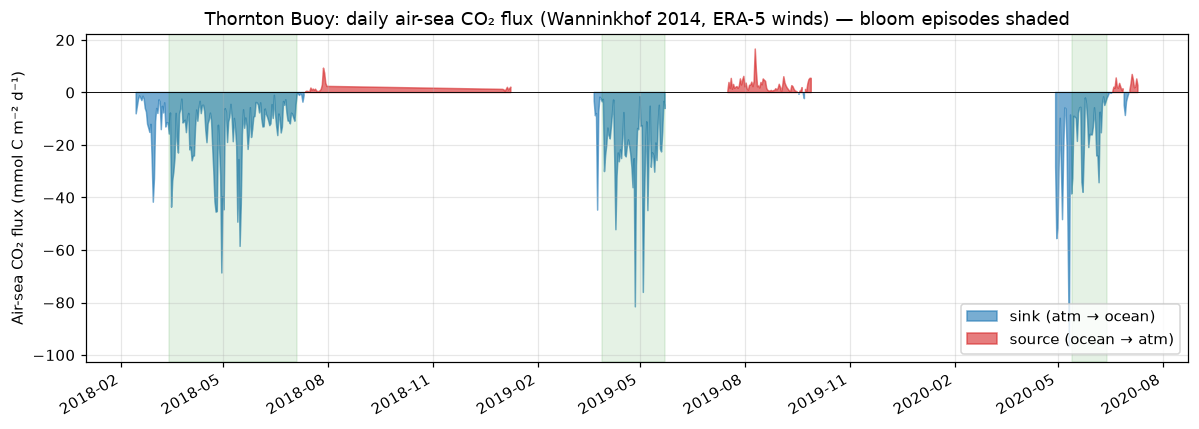

In [19]:
# Plot: daily flux with bloom episodes shaded; negative = ocean sink
fig, ax = plt.subplots(figsize=(11, 4.0))
ax.fill_between(flux.index, flux["F_mmolC_m2_d"], 0,
                where=flux["F_mmolC_m2_d"] < 0, color="tab:blue",  alpha=0.6, label="sink (atm → ocean)")
ax.fill_between(flux.index, flux["F_mmolC_m2_d"], 0,
                where=flux["F_mmolC_m2_d"] >= 0, color="tab:red",  alpha=0.6, label="source (ocean → atm)")
ax.axhline(0, color="k", lw=0.6)
for s, e in runs:
    ax.axvspan(s, e, color="green", alpha=0.10)
ax.set_ylabel("Air-sea CO₂ flux (mmol C m⁻² d⁻¹)")
ax.set_title("Thornton Buoy: daily air-sea CO₂ flux (Wanninkhof 2014, ERA-5 winds) — bloom episodes shaded")
ax.legend(loc="lower right")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()

In [20]:
# Integrated CO2 uptake per bloom episode
rows = []
for s, e in runs:
    sub = flux.loc[s:e]
    if sub.empty: continue
    rows.append({
        "start"            : s.date(),
        "end"              : e.date(),
        "n_days"           : len(sub),
        "mean_U10_m_s"     : sub["U10_mean"].mean(),
        "mean_dpCO2_uatm"  : (sub["pco2"] - PCO2_ATM).mean(),
        "mean_flux_mmolC_m2_d" : sub["F_mmolC_m2_d"].mean(),
        "total_uptake_gC_m2"   : -sub["F_gC_m2_d"].sum(),   # positive = sink
    })
episodes_flux = pd.DataFrame(rows)
episodes_flux.style.format({
    "mean_U10_m_s":"{:.2f}", "mean_dpCO2_uatm":"{:.1f}",
    "mean_flux_mmolC_m2_d":"{:.2f}", "total_uptake_gC_m2":"{:.1f}",
})

,start,end,n_days,mean_U10_m_s,mean_dpCO2_uatm,mean_flux_mmolC_m2_d,total_uptake_gC_m2
0,2018-03-15,2018-07-05,113,6.04,-171.5,-15.23,20.7
1,2019-03-29,2019-05-23,56,5.90,-249.6,-21.94,14.8
2,2020-05-13,2020-06-13,32,6.24,-151.9,-14.75,5.7


**Reading the bloom budget**

Each spring the southern North Sea takes up of order **tens of grams of carbon
per square metre** at this site — the integral of weeks of strong drawdown
(ΔpCO₂ < -200 µatm) and moderate winds (5-8 m s⁻¹). For comparison, the global
mean ocean uptake is ~1-2 mol C m⁻² yr⁻¹ ≈ 12-24 g C m⁻² yr⁻¹. The bloom
delivers a substantial fraction of the annual flux **in a single 6-8-week
window**, then partly gives it back in summer as respiration drives ΔpCO₂
positive and the area briefly flips to a CO₂ source.

**Caveats**

* `pCO₂_atm = 410 µatm` is a fixed reference for 2018-2020; an evolving
  monthly value (e.g. from Mauna Loa or a nearby ICOS atmospheric station)
  would shift the budget by a few percent.
* Wanninkhof 2014 uses the *daily mean of U²*, not (daily mean U)² — that's
  done above by averaging `u10² + v10²` directly.
* The buoy is a coastal point; for an areal budget, combine with the
  `11SS*` (Belgian) and `58G2*`/`MLSC*` (northern) cruises.
* Single-point Wanninkhof short-term k has ~20-30% systematic uncertainty;
  the bloom *direction* and *order of magnitude* are robust, the precise
  total g C m⁻² is not.


## 11. Reusable access snippet

In [21]:
# Minimal pattern to access any SOCAT cruise from the ICOS zarr.
# Use open_consolidated() — the store relies on its 12 MB .zmetadata index,
# and open_consolidated() fails loudly if that index can't be fetched
# instead of silently returning an empty group.
import zarr, fsspec
mapper = fsspec.get_mapper("https://zarr.icos-cp.eu/icos-socat.zarr")
g = zarr.open_consolidated(mapper, mode="r")[GID]   # any expocode from `cruises`
t    = g["time"][:]
sst  = g["Temp"][:]
pco2 = g["pCO2"][:]
ok   = (g["Temp_QC"][:] == 2) & (g["pCO2_QC"][:] == 2)

## 12. Next steps for a fuller picture

* **Independent algae confirmation:** pair this with a satellite chlorophyll-a
  product (e.g. **Copernicus Marine `OCEANCOLOUR_ATL_BGC_L4_MY`** — daily L4,
  also zarr-friendly). The ICOS zarr does *not* expose chl-a even though the
  Thornton Buoy hardware measures it.
* **Areal coverage:** combine fixed buoys with the `11SS*` RV Simon Stevin
  transects (southern N. Sea, monthly) and the `58G2*` / `MLSC*` northern
  cruises to map bloom onset latitude-by-latitude.
* **Time-varying atmospheric pCO₂:** replace the constant 410 µatm with a
  monthly series from a nearby ICOS atmospheric tower (`icos-obspack.zarr`,
  station CBW for the southern North Sea) or NOAA Mauna Loa.
